# 01 · Tokenization — text to numbers

Machines only handle numbers. Step one: chop text into **tokens** (word pieces) and give each
an integer **id**. Modern LLMs use **BPE** (Byte-Pair Encoding), learned from a huge corpus:

1. Start from single characters.
2. Repeatedly merge the **most frequent adjacent pair** into a new token.
3. After ~100k merges you have the vocabulary. Frequent chunks (`the`, `ing`, `transform`)
   become single tokens; rare words split into several.

Why it matters: you're billed **per token**, and context limits (e.g. 128k) count tokens, not
characters.

In [4]:
import tiktoken
enc = tiktoken.get_encoding("cl100k_base")   # the GPT-4 tokenizer

for t in ["transformers", "Transformers", " Transformers", "transformer", "transform"]:
    ids = enc.encode(t)
    print(f"{t!r:16} -> {str(ids):14} -> {[enc.decode([i]) for i in ids]}")

'transformers'   -> [4806, 388]    -> ['transform', 'ers']
'Transformers'   -> [9140, 388]    -> ['Transform', 'ers']
' Transformers'  -> [81632]        -> [' Transformers']
'transformer'    -> [4806, 261]    -> ['transform', 'er']
'transform'      -> [4806]         -> ['transform']


### Read the output — three lessons

- `transform` is a super-common English root, so it earned its **own token**.
- `transformers` (bare) is rarer, so it splits into `transform` + `ers` (both existing pieces).
- **Surprise:** `' Transformers'` **with a leading space** is a *single* token! In real text
  words follow spaces (`"the Transformers movie"`), so BPE saw `" Transformers"` often enough
  to give it one token. **The leading space is part of the token.**

Consequence: `"cat"`, `" cat"`, `"Cat"` are *different* token sequences. Spacing and casing
change what the model actually sees.

[1, 1, 3, 6, 7]
[3, 4, 12, 28, 17]


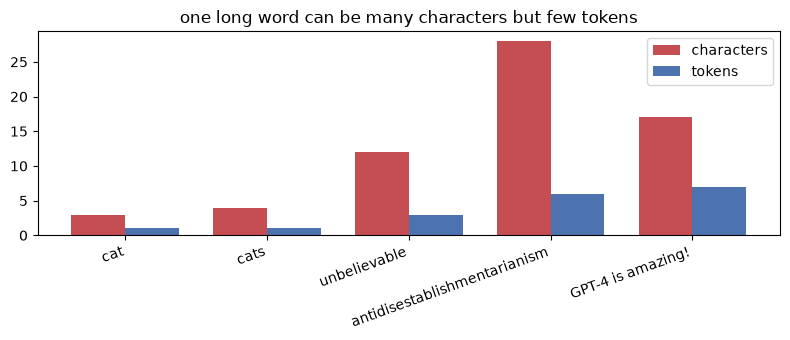

In [ ]:
# Tokens are NOT words. Watch the token count vs character count.
import matplotlib.pyplot as plt

samples = ["cat", "cats", "unbelievable", "antidisestablishmentarianism", "GPT-4 is amazing!"]
n_tokens = [len(enc.encode(s)) for s in samples]

n_chars  = [len(s) for s in samples]

x = range(len(samples))
w = 0.38
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar([i - w/2 for i in x], n_chars,  w, label="characters", color="#C44E52")
ax.bar([i + w/2 for i in x], n_tokens, w, label="tokens",     color="#4C72B0")
ax.set_xticks(list(x))
ax.set_xticklabels(samples, rotation=20, ha="right")
ax.set_title("one long word can be many characters but few tokens")
ax.legend()
plt.tight_layout()
plt.show()

**Takeaway.** Tokenization = text → integer ids via frequency-learned BPE pieces. A token is
roughly 0.75 English words. Spacing/casing matter. Next: **02 · embeddings** — turning those
ids into meaning.